**AI And ML**

**Student Id:** 2417514

**Student Name**: Suvina Thapa

Workshop 5


In [20]:
from tensorflow.keras.layers import Conv2D

layer = Conv2D(
    filters=32,
    kernel_size=(3,3),
    strides=(1,1),
    padding="valid",
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform"
)

In [21]:
#Syntax of Pooling Layers
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D
max_pool = MaxPooling2D(pool_size=(2,2), strides=None, padding="valid")
avg_pool = AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9605 - loss: 0.1286 - val_accuracy: 0.9842 - val_loss: 0.0508
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9905 - val_loss: 0.0323
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.9909 - loss: 0.0302 - val_accuracy: 0.9859 - val_loss: 0.0423
Epoch 4/5
1734/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9932 - loss: 0.0206

#7 Exercise
Implement an End to End CNN Model for Image CLassification Task



In [24]:
#import library
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split


#Uploading and extracting the datatset zip
from google.colab import drive
import zipfile, os

# Mount your Drive
drive.mount('/content/drive')

# Extract directly from Drive — no re-upload needed ever again
zip_path = "/content/drive/MyDrive/AI And ML/Week5/FruitinAmazon.zip"

if not os.path.exists("dataset"):
    os.makedirs("dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("dataset/")

print("Extracted successfully!")

# Auto-find train/ and test/
def find_subdir(root, name):
    for dirpath, dirnames, _ in os.walk(root):
        if name in dirnames:
            return os.path.join(dirpath, name)
    return None

train_dir = find_subdir("dataset", "train")
test_dir  = find_subdir("dataset", "test")
print(f"Train: {train_dir}")
print(f"Test:  {test_dir}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted successfully!
Train: dataset/FruitinAmazon/train
Test:  dataset/FruitinAmazon/test


TASK 1a: Visualising sample images per class
*********************************************
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



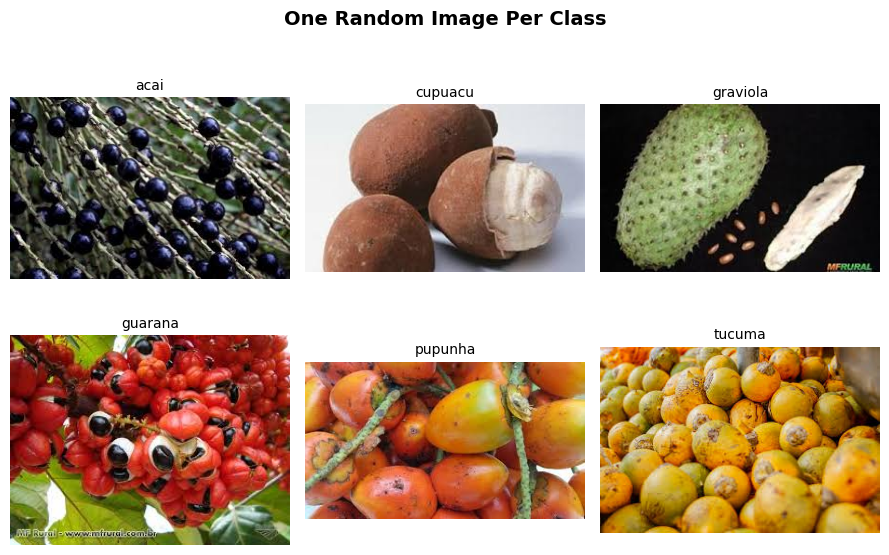

In [14]:
#Task1 Visualizing one random image per class
print("TASK 1a: Visualising sample images per class")
print("*" * 45)
# Get sorted list of class folder names
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print(f"Classes found: {class_dirs}\n")

#Selecting one image randomly from each clas
sample_images = []
sample_labels = []
for cls in class_dirs:
  cls_path = os.path.join(train_dir, cls)
  all_images = [
      f for f in os.listdir(cls_path)
      if f.lower().endswith((".jpeg"))
  ]
  if all_images:
    choosen = random.choice(all_images)
    sample_images.append(os.path.join(cls_path, choosen))
    sample_labels.append(cls)

#plotting in 2 grid row
num_images = len(sample_images)
#Division for euqal columns
num_cols = (num_images + 1) // 2
num_rows = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, 6))
axes = axes.flatten()

for i, (image_path, label) in enumerate(zip(sample_images, sample_labels)):
  img = Image.open(image_path).convert("RGB")
  axes[i].imshow(img)
  axes[i].set_title(label, fontsize=10)
  axes[i].axis("off")

# Turing off any empty sub plot axis
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Random Image Per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task1_sample_images.png", dpi=150)
plt.show()







#task1a Observation

-> Images of jpeg belong to different visual fruit class and image vary in sizes,background and lighting condition which shows the need of resizing and normalization.

In [25]:
#Task 1b Checking for and removing corrupted images
print("TASK 1b: Checking for corrupted images")
print("*" * 45)

#List to track all corrupted images
corrupted_images = []
for cls in class_dirs:
  cls_path = os.path.join(train_dir, cls)
  for fname in os.listdir(cls_path):
    if not fname.lower().endswith(('.jpeg')):
      continue

    image_path = os.path.join(cls_path, fname)
    try:
      with Image.open(image_path) as img:
        #verifying file integreity
        img.verify()
    except(IOError, SyntaxError) as e:
      print(f"Invalid image: {image_path}")

if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal removed: {len(corrupted_images)}")
print()



TASK 1b: Checking for corrupted images
*********************************************
No Corrupted Images Found.



In [30]:
#Task2 Loading and Preprocessing Image data in keras
print("TASK 2: Loading and Preprocessing Image data in Keras")
print("*" * 45)

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

#Normalization by dividing every pixel by 255
rescale = tf.keras.layers.Rescaling(1./255)

#Training Datatset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = True, validation_split = validation_split, subset = 'training', seed = 123
)
class_names = train_ds.class_names
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#Validation datatset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = False, validation_split = validation_split, subset = 'validation', seed = 123)
val_ds = val_ds.map(lambda x, y:(rescale(x), y))

#Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels = 'inferred', label_mode = 'int',image_size= (img_height, img_width),interpolation = 'nearest',batch_size    = batch_size,
    shuffle = False,seed = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Class names are inferred from folder names (same order as integer labels)

num_classes = len(class_names)
print(f"Classes : {class_names}")
print(f"Total   : {num_classes} classes\n")


TASK 2: Loading and Preprocessing Image data in Keras
*********************************************
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total   : 6 classes



In [35]:
#Task3 Implementing CNN
print("TASK 3: Building the CNN")
print("=" * 35)

model = tf.keras.Sequential([

    # Convolutional Layer 1 + ReLU activation + Pooling Layer 1
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu',
        input_shape = (img_height, img_width, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2 + ReLU activation + Pooling Layer 2
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
      # Flatten layer
    tf.keras.layers.Flatten(),

    # Hidden Layer 1 – 128 neurons
    tf.keras.layers.Dense(128, activation='relu'),

    # Hidden Layer 2 – 64 neurons
    tf.keras.layers.Dense(64, activation='relu'),

    # Output Layer – one neuron per class (raw logits)
    tf.keras.layers.Dense(num_classes)
])

model.summary()
print()

TASK 3: Building the CNN


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

TASK 4: Compiling the model
Model compiled.

TASK 4: Training the model
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1233 - loss: 2.7929
Epoch 1: val_loss improved from None to 1.66350, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 479ms/step - accuracy: 0.1111 - loss: 2.8346 - val_accuracy: 0.1667 - val_loss: 1.6635
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.2184 - loss: 1.8521
Epoch 2: val_loss did not improve from 1.66350
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.2222 - loss: 1.8260 - val_accuracy: 0.1111 - val_loss: 1.7551
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3677 - loss: 1.7556
Epoch 3: val_loss did not improve from 1.66350
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.3750 - loss: 1.7444 - val_accuracy: 0.2222 - val_loss: 1.7194
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2365 - loss: 1.7145
Epoch 4: val_loss improved from 1.66350 to 1.64908, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.2500 - loss: 1.6953 - val_accuracy: 0.6111 - val_loss: 1.6491
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5913 - loss: 1.5424
Epoch 5: val_loss improved from 1.64908 to 1.43175, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 474ms/step - accuracy: 0.5972 - loss: 1.5201 - val_accuracy: 0.7222 - val_loss: 1.4318
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5146 - loss: 1.3486
Epoch 6: val_loss improved from 1.43175 to 1.38313, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 556ms/step - accuracy: 0.5417 - loss: 1.2967 - val_accuracy: 0.3889 - val_loss: 1.3831
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6399 - loss: 1.0330
Epoch 7: val_loss improved from 1.38313 to 0.73936, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.6528 - loss: 1.0346 - val_accuracy: 0.8889 - val_loss: 0.7394
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8215 - loss: 0.7769
Epoch 8: val_loss did not improve from 0.73936
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.8472 - loss: 0.7295 - val_accuracy: 0.7222 - val_loss: 1.0931
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9080 - loss: 0.4087
Epoch 9: val_loss improved from 0.73936 to 0.34371, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.8472 - loss: 0.4567 - val_accuracy: 0.8889 - val_loss: 0.3437
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9882 - loss: 0.1869
Epoch 10: val_loss did not improve from 0.34371
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.9722 - loss: 0.2134 - val_accuracy: 0.8889 - val_loss: 0.5973
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 1.0000 - loss: 0.1276
Epoch 11: val_loss did not improve from 0.34371
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 1.0000 - loss: 0.1007 - val_accuracy: 0.8889 - val_loss: 0.5878
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9396 - loss: 0.1928
Epoch 12: val_loss did not improve from 0.34371
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.9583 - loss: 0.1393 - val_accuracy: 0.8333 - val_loss: 0.5733
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 1.0000 - loss: 0.0425
Epo


Epoch 14: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 1.0000 - loss: 0.0353 - val_accuracy: 0.9444 - val_loss: 0.1801
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 1.0000 - loss: 0.0128
Epoch 15: val_loss improved from 0.18013 to 0.17113, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.8889 - val_loss: 0.1711
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 1.0000 - loss: 0.0139
Epoch 16: val_loss did not improve from 0.17113
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8889 - val_loss: 0.1889
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 1.0000 - loss: 0.0027
Epoch 17: val_loss did not improve from 0.17113
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_loss: 0.2780
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 18: val_loss did not improve from 0.17113
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8889 - val_loss: 0.3600
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 1.0000 - loss: 0.0013
Ep

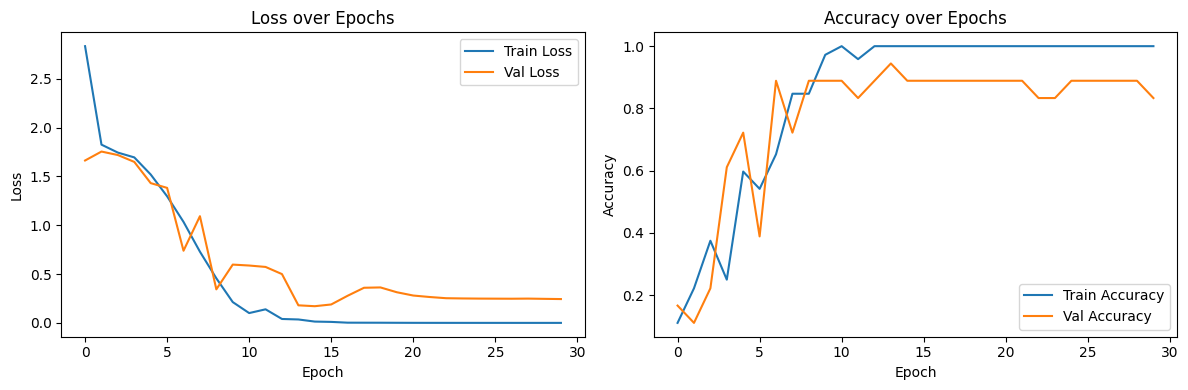

Training curves saved → task4_training_curves.png



In [36]:
#Task4 Compliling Mode
print("TASK 4: Compiling the model")
print("=" * 35)

model.compile(
    optimizer = 'adam',
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics   = ['accuracy']
)
print("Model compiled.\n")

print(" Training the model")
print("=" * 35)

# Reload datasets with batch_size = 16 as required
train_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = 16,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)
train_ds16 = train_ds16.map(lambda x, y: (rescale(x), y))

val_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = 16,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)
val_ds16 = val_ds16.map(lambda x, y: (rescale(x), y))

callbacks = [
    # Save the model only when val_loss improves
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = 'best_model.h5',
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    # Stop training if val_loss does not improve for 15 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 15,
        verbose              = 1,
        restore_best_weights = True
    )
]

history = model.fit(
    train_ds16,
    validation_data = val_ds16,
    epochs          = 250,
    callbacks       = callbacks
)

# Plot training and validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss over Epochs/n')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig("task4_training_curves.png", dpi=150)
plt.show()
print("Training curves saved → task4_training_curves.png\n")

In [37]:
#Task 5 Evaluating the Model on Test set
print("TASK 5: Evaluating on the test set")
print("=" * 35)

test_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = 16,
    shuffle       = False,
    seed          = 123
)
test_ds16 = test_ds16.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds16, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%\n")

TASK 5: Evaluating on the test set
Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6000 - loss: 1.2946

Test Loss     : 1.2946
Test Accuracy : 60.00%



In [39]:
#Task 6: Saving and load the Model
print("TASK 6: Saving and loading the model")
print("=" * 35)

# Save
model.save('final_model.h5')
print("Model saved → final_model.h5")

# Load
loaded_model = tf.keras.models.load_model('final_model.h5')
print("Model loaded successfully.")

# Re-evaluate with loaded model (should give identical results)
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds16, verbose=1)
print(f"\nTest Loss     : {loaded_loss:.4f}")
print(f"Test Accuracy : {loaded_acc * 100:.2f}%\n")


TASK 6: Saving and loading the model
Model saved → final_model.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.6000 - loss: 1.2946

Test Loss     : 1.2946
Test Accuracy : 60.00%



TASK 7: Predictions & Classification Report

Classification Report:

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.42      1.00      0.59         5
    graviola       1.00      0.40      0.57         5
     guarana       0.62      1.00      0.77         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.60        30
   macro avg       0.74      0.60      0.57        30
weighted avg       0.74      0.60      0.57        30



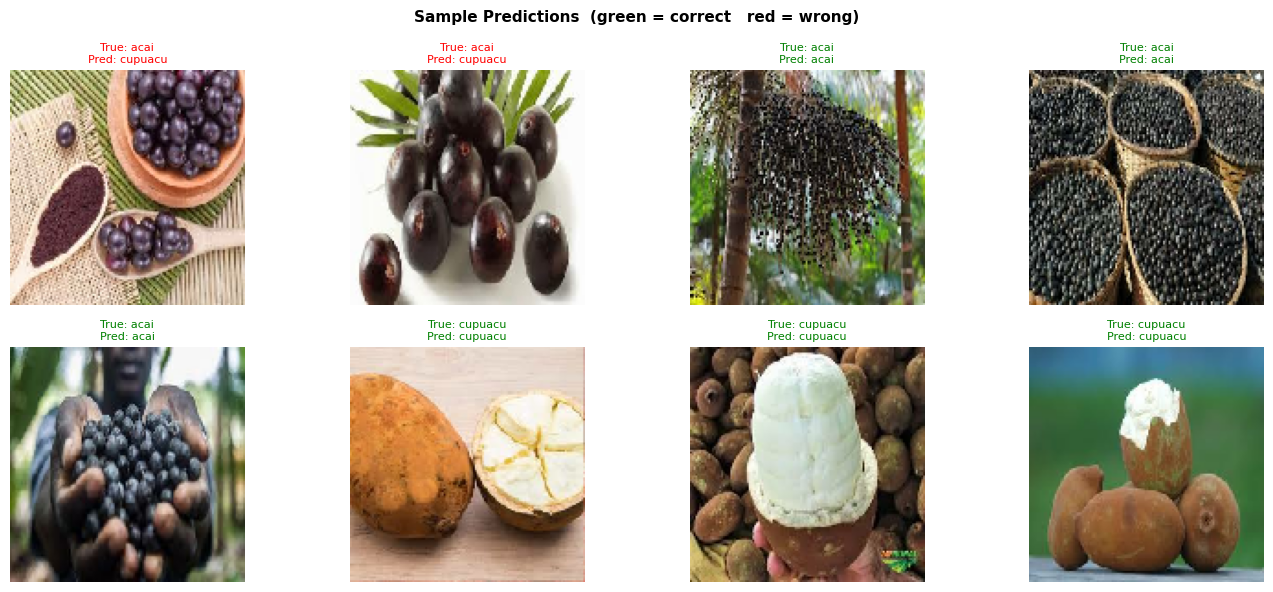


Predictions saved as task7_predictions.png


In [48]:
#Task7 Predictions and Classifcation
from sklearn.metrics import classification_report
print("TASK 7: Predictions & Classification Report")
print("=" * 45)

all_preds  = []
all_labels = []

for images, labels in test_ds16:
    # Get raw logits from model
    logits = loaded_model.predict(images, verbose=0)
    # Convert logits to predicted class labels
    preds  = np.argmax(logits, axis=1)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Print Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,target_names = class_names
))
# Show 8 sample predictions visually (green = correct, red = wrong)
sample_imgs = []
sample_true = []
sample_pred = []

for images, labels in test_ds16.take(1):
    logits = loaded_model.predict(images, verbose=0)
    preds  = np.argmax(logits, axis=1)
    for i in range(min(8, len(images))):
        sample_imgs.append(images[i].numpy())
        sample_true.append(class_names[labels[i]])
        sample_pred.append(class_names[preds[i]])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i in range(len(sample_imgs)):
    axes[i].imshow(sample_imgs[i])
    colour = "green" if sample_true[i] == sample_pred[i] else "red"
    axes[i].set_title(
        f"True: {sample_true[i]}\nPred: {sample_pred[i]}",
        color=colour, fontsize=8
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions  (green = correct   red = wrong)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("\ntask7_predictions.png", dpi=150)
plt.show()
print("\nPredictions saved as task7_predictions.png")

